### Sutton advection problem — general solver

This notebook implements and evaluates a 2-D boundary-layer advection model based on Sutton's problem, describing how temperature and water vapour redistribute downwind of an abrupt surface discontinuity (e.g. fallow → irrigated land).

**What it does:**

1. **Setup & physical constants** — imports from the `sutton` package, defines atmospheric constants ($\rho$, $c_p$, $L_v$, $\sigma_{SB}$), and sets boundary conditions .

2. **AdvectionParams dataclass** —  parameter class with per-patch canopy geometry, energy partition, radiation closure, and implicit advection solvers for temperature and water vapour.
   - defines per-patch canopy geometry, flexible moisture specification (RH or $Q$), energy partition ($H_f$, $LE_f$, `avail_ratio`, `le_factor`), and methods to:
   - solve for incoming shortwave and albedo from energy balance (`solve_surface_radiation_inplace`),
   - derive surface boundary conditions from fluxes via log-law (`update_surface_BCs_from_reference`),
   - reconcile prescribed surface temperatures with sensible heat (`reconcile_heat_with_prescribed_surface_T`).

3. **Implicit advection solver** — marches temperature (`uniform_T`) and absolute humidity (`uniform_Q`) fields downwind using an implicit finite-difference scheme (Thomas algorithm), with mixing-length eddy diffusivity.

5. **Flux diagnostics** — converts kinematic fluxes to $\text{W m}^{-2}$, plots sensible and latent heat flux profiles along fetch, examines the Bowen ratio evolution, and fits exponential decay curves to the flux adjustment.

6. **2-D fields** — contour plots of Q and its vertical flux across the (x, z) domain.

`solve_surface_radiation_inplace(fix="alpha_c") calls a two-equation algebraic "radiation closure" that back-solves for an incoming shortwave value and an albedo so that the net radiation on each surface matches the available energy prescribed via $R_n$ and $G$ upwind and downwind of the transition.


 1.  Define target net radiation for each patch

- The routine first constructs the *target* net radiation for the fallow (upwind) and cultivated (downwind) surfaces

 2.  Assume a simple net-radiation model for each surface

For each surface type, the code uses:
$$
R_{n,s} = SW\,(1-\alpha_s)
\;+\; \varepsilon_a \sigma T_a^4 \;-\; \varepsilon_s \sigma T_s^4,
$$

where 
- $SW$ is incoming shortwave
- $\alpha_s$ is the surface albedo
- $\varepsilon_a$ is an effective atmospheric emissivity, 
- $\varepsilon_s$ is the surface emissivity, and 
- $\sigma$ is the Stefan--Boltzmann constant. 

Temperatures are converted to Kelvin internally:
$$
T_K = T_{\mathrm{C}} + 273.15.
$$

Thus the two balances are:
$$
SW(1-\alpha_f) + \varepsilon_a\sigma T_a^4 - \varepsilon_f\sigma T_{sf}^4 = R_{n,f}
$$

$$
SW(1-\alpha_c) + \varepsilon_a\sigma T_a^4 - \varepsilon_c\sigma T_{sc}^4 = R_{n,c}
$$

 3)  With `fix="alpha_c"`, $\alpha_c$ is treated as known (held at $alpha_c$), and the unknowns are $SW \quad$ $\alpha_f$.

Sympy solves the resulting $2\times 2$ system (linear in the unknowns).

Equivalently, the solution can be written explicitly as
$$SW = \frac{R_{n,c} - \varepsilon_a\sigma T_a^4 + \varepsilon_c\sigma T_{sc}^4}{1-\alpha_c}$$

$$\alpha_f = 1 - \frac{R_{n,f} - \varepsilon_a\sigma T_a^4 + \varepsilon_f\sigma T_{sf}^4}{SW}.
$$

4. After solving, the routine updates the parameter object:
- $\texttt{p.SW\_in} \leftarrow SW$,
- $\texttt{p.alpha\_f} \leftarrow \alpha_f$ (clipped to $[0,1]$).

### Including relative humidity

Convert vapor concentration $Q$ (in $\mathrm{g\,m^{-3}}$) to vapor pressure $e$ (Pa) using the ideal-gas law for water vapor:
$$
e = \rho_v R_v T,
\qquad
\rho_v = \frac{Q}{1000},
$$

where 
- $\rho_v$ is water vapor density in $\mathrm{kg\,m^{-3}}$, 
- $R_v$ is the specific gas constant for water vapor, and
- $T$ is absolute temperature (K).

Then compute relative humidity as
$$
RH = 100\,\frac{e}{e_s(T)},
$$

where $e_s(T)$ is the saturation vapor pressure at temperature $T$.

In [1]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import pandas as pd



CPU times: user 1.51 s, sys: 1.74 s, total: 3.25 s
Wall time: 3.54 s


### Parameter dataclass & solver functions
Extended parameter class with per-patch canopy geometry, energy partition, radiation closure, and implicit advection solvers for temperature and water vapour.

In [2]:
import sys
sys.path.insert(0, "/Users/octaviacrompton/Projects/sutton_advection/src")

# Project imports
from sutton import (
    AdvectionParams,
    Params,
    thomas,
    our_central_difference,
    no_central_difference,
    saturation_vapor_pressure,
    vapor_concentration_RH,
    SIGMA_SB, CP_AIR, RHO_AIR, LV, LV_G, RV,
)

### Boundary conditions

In [3]:
# ---- Physical constants (aliased from sutton.constants for use in helper cells below) ----
sigma_sb = SIGMA_SB   # W m^-2 K^-4  (Stefan–Boltzmann)
cp_air   = CP_AIR     # J kg^-1 K^-1
rho_air  = RHO_AIR    # kg m^-3
Lv       = LV         # J kg^-1
Lv_g     = LV_G       # J g^-1  (~30 °C)
Rv       = RV         # J kg^-1 K^-1  (water-vapour gas constant)

# They are NOT used by AdvectionParams — the dataclass has its own fields.


In [4]:
def print_radiation_budget(p: "AdvectionParams", 
                           sigma: float = SIGMA_SB, digits: int = 2) -> dict:
    """
    Print (and return) the upwind (f) and downwind (c) radiation-budget terms
    consistent with p.solve_surface_radiation_inplace().

    Uses:
      Rn = SW*(1-alpha) + eps_a*sigma*Ta^4 - eps_s*sigma*Ts^4
      target Rn_f = RNmG_up + G
      target Rn_c = RNmG_down + G
    """
    def K(Tc): return Tc + 273.15

    SW   = float(p.SW_in)
    TaK  = K(float(p.T_a))
    TsfK = K(float(p.T_sf))
    TscK = K(float(p.T_sc))

    # Common atmospheric longwave down term in this simplified closure
    LW_down = float(p.epsilon_a) * sigma * TaK**4

    # --- Upwind / fallow (f) ---
    SWabs_f = SW * (1.0 - float(p.alpha_f))
    LWup_f  = float(p.epsilon_f) * sigma * TsfK**4
    Rn_f    = SWabs_f + LW_down - LWup_f
    RNmG_f  = Rn_f - float(p.G)
    Rn_f_target = float(p.RNmG_up) + float(p.G)

    # --- Downwind / cultivated (c) ---
    SWabs_c = SW * (1.0 - float(p.alpha_c))
    LWup_c  = float(p.epsilon_c) * sigma * TscK**4
    Rn_c    = SWabs_c + LW_down - LWup_c
    RNmG_c  = Rn_c - float(p.G)
    Rn_c_target = float(p.RNmG_down) + float(p.G)

    out = {
        "common": {
            "SW_in": SW,
            "Ta_K": TaK,
            "LW_down": LW_down,
            "G": float(p.G),
            "RNmG_up": float(p.RNmG_up),
            "RNmG_down": float(p.RNmG_down),
        },
        "upwind_f": {
            "alpha_f": float(p.alpha_f),
            "epsilon_f": float(p.epsilon_f),
            "Ts_K": TsfK,
            "SW_absorbed": SWabs_f,
            "LW_up": LWup_f,
            "Rn": Rn_f,
            "Rn_minus_G": RNmG_f,
            "Rn_target": Rn_f_target,
            "Rn_mismatch": Rn_f - Rn_f_target,
        },
        "downwind_c": {
            "alpha_c": float(p.alpha_c),
            "epsilon_c": float(p.epsilon_c),
            "Ts_K": TscK,
            "SW_absorbed": SWabs_c,
            "LW_up": LWup_c,
            "Rn": Rn_c,
            "Rn_minus_G": RNmG_c,
            "Rn_target": Rn_c_target,
            "Rn_mismatch": Rn_c - Rn_c_target,
        },
    }

    r = lambda x: float(np.round(x, digits))

    print("=== Radiation budget (closure-consistent) ===")
    print(f"SW_in = {r(SW)} W m^-2")
    print(f"Ta = {r(p.T_a)} °C  ({r(TaK)} K)")
    print(f"eps_a = {p.epsilon_a}  => LW_down = eps_a*sigma*Ta^4 = {r(LW_down)} W m^-2")
    print(f"G = {r(p.G)} W m^-2")
    print(f"Targets: RNmG_up = {r(p.RNmG_up)} , RNmG_down = {r(p.RNmG_down)}  (W m^-2)")
    print()

    print("--- Upwind (f) ---")
    print(f"alpha_f={p.alpha_f}, eps_f={p.epsilon_f}, Ts_f={r(p.T_sf)} °C ({r(TsfK)} K)")
    print(f"  SW_abs = SW*(1-alpha_f) = {r(SWabs_f)}")
    print(f"  LW_up  = eps_f*sigma*Ts^4 = {r(LWup_f)}")
    print(f"  Rn     = {r(Rn_f)}   |  Rn-G = {r(RNmG_f)}")
    print(f"  target Rn = RNmG_up + G = {r(Rn_f_target)}   | mismatch = {r(Rn_f - Rn_f_target)}")
    print()

    print("--- Downwind (c) ---")
    print(f"alpha_c={p.alpha_c}, eps_c={p.epsilon_c}, Ts_c={r(p.T_sc)} °C ({r(TscK)} K)")
    print(f"  SW_abs = SW*(1-alpha_c) = {r(SWabs_c)}")
    print(f"  LW_up  = eps_c*sigma*Ts^4 = {r(LWup_c)}")
    print(f"  Rn     = {r(Rn_c)}   |  Rn-G = {r(RNmG_c)}")
    print(f"  target Rn = RNmG_down + G = {r(Rn_c_target)}   | mismatch = {r(Rn_c - Rn_c_target)}")

    return out


In [5]:
def print_surface_moisture_check(p: "AdvectionParams", digits: int = 3) -> dict:
    """
    Print (and return) surface moisture consistency checks at the upwind (f) and
    downwind (c) surfaces using your conventions:

      T in °C
      Q in g m^-3 (absolute humidity / vapor concentration)
      RH in %

    It reports:
      - RH implied by (T, Q)
      - Q implied by (T, RH) (if RH is available)
      - mismatches vs stored RH/Q
      - saturation vapor concentration Q_sat(T) (g m^-3)
    """
    def K(Tc): return float(Tc) + 273.15

    # --- helpers (standalone so this works even if you refactor AdvectionParams later) ---
    def RH_from_Q(Tc: float, Q_gm3: float) -> float:
        Tk = K(Tc)
        rho_v = float(Q_gm3) / 1000.0                # kg m^-3
        e = rho_v * Rv * Tk                          # Pa
        es = saturation_vapor_pressure(Tk)            # Pa
        return 100.0 * (e / es)

    def Q_from_RH(Tc: float, RH_pct: float) -> float:
        return float(vapor_concentration_RH(float(Tc), float(RH_pct)))  # g m^-3

    def r(x):
        if x is None:
            return None
        return float(np.round(float(x), digits))

    # pull stored values (RH_f may not exist yet)
    RHc_stored = getattr(p, "RH_c", None)
    RHf_stored = getattr(p, "RH_f", None)

    Tc, Tf = float(p.T_sc), float(p.T_sf)
    Qc, Qf = float(p.Q_c), float(p.Q_f)

    # implied from (T, Q)
    RHc_fromQ = RH_from_Q(Tc, Qc)
    RHf_fromQ = RH_from_Q(Tf, Qf)

    # implied from (T, RH) if RH exists
    Qc_fromRH = Q_from_RH(Tc, RHc_stored) if RHc_stored is not None else None
    Qf_fromRH = Q_from_RH(Tf, RHf_stored) if RHf_stored is not None else None

    # saturation vapor concentration at each surface
    Qsat_c = Q_from_RH(Tc, 100.0)
    Qsat_f = Q_from_RH(Tf, 100.0)

    out = {
        "downwind_c": {
            "T_C": Tc, "T_K": K(Tc),
            "Q_gm3": Qc,
            "RH_stored_pct": RHc_stored,
            "RH_from_Q_pct": RHc_fromQ,
            "RH_mismatch_pct": (RHc_fromQ - float(RHc_stored)) if RHc_stored is not None else None,
            "Q_from_RH_gm3": Qc_fromRH,
            "Q_mismatch_gm3": (Qc_fromRH - Qc) if Qc_fromRH is not None else None,
            "Q_sat_gm3": Qsat_c,
        },
        "upwind_f": {
            "T_C": Tf, "T_K": K(Tf),
            "Q_gm3": Qf,
            "RH_stored_pct": RHf_stored,
            "RH_from_Q_pct": RHf_fromQ,
            "RH_mismatch_pct": (RHf_fromQ - float(RHf_stored)) if RHf_stored is not None else None,
            "Q_from_RH_gm3": Qf_fromRH,
            "Q_mismatch_gm3": (Qf_fromRH - Qf) if Qf_fromRH is not None else None,
            "Q_sat_gm3": Qsat_f,
        }
    }

    print("=== Surface moisture check (T, Q, RH) ===")
    print("Conventions: T in °C, Q in g m^-3, RH in %")
    print()

    # --- downwind (c) ---
    c = out["downwind_c"]
    print("--- Downwind surface (c) ---")
    print(f"T_sc = {r(c['T_C'])} °C  ({r(c['T_K'])} K)")
    print(f"Q_c  = {r(c['Q_gm3'])} g m^-3   | Q_sat(T_sc) = {r(c['Q_sat_gm3'])} g m^-3")
    print(f"RH implied by (T_sc, Q_c): {r(c['RH_from_Q_pct'])} %")
    if c["RH_stored_pct"] is not None:
        print(f"RH stored: {r(c['RH_stored_pct'])} %   | mismatch = {r(c['RH_mismatch_pct'])} %")
        print(f"Q implied by (T_sc, RH_stored): {r(c['Q_from_RH_gm3'])} g m^-3"
              f"   | mismatch vs Q_c = {r(c['Q_mismatch_gm3'])} g m^-3")
    else:
        print("RH stored: None (only reporting RH implied by Q)")
    print()

    # --- upwind (f) ---
    f = out["upwind_f"]
    print("--- Upwind surface (f) ---")
    print(f"T_sf = {r(f['T_C'])} °C  ({r(f['T_K'])} K)")
    print(f"Q_f  = {r(f['Q_gm3'])} g m^-3   | Q_sat(T_sf) = {r(f['Q_sat_gm3'])} g m^-3")
    print(f"RH implied by (T_sf, Q_f): {r(f['RH_from_Q_pct'])} %")
    if f["RH_stored_pct"] is not None:
        print(f"RH stored: {r(f['RH_stored_pct'])} %   | mismatch = {r(f['RH_mismatch_pct'])} %")
        print(f"Q implied by (T_sf, RH_stored): {r(f['Q_from_RH_gm3'])} g m^-3"
              f"   | mismatch vs Q_f = {r(f['Q_mismatch_gm3'])} g m^-3")
    else:
        print("RH stored: None (only reporting RH implied by Q)")

    return out


In [6]:
level = 1  # initial solver level; redefined as _level in downstream cells
ustar_f = 0.75
shear_ratio = 1
ustar_c = ustar_f*np.sqrt(shear_ratio)

p = AdvectionParams(ustar_f = ustar_f, 
                    ustar_c = ustar_c, 
                    lm_option = 'kz', 
                    lm_zshift = 0.0005,
                    zom_c = 0.0005,
                    avail_ratio =  1.8, 
                    Hmax = 2,
                    le_factor = 1.35, 
                    dz = 0.005, 
                    dx = 0.2,
                    Q_a = 6.5,
                    Q_f = 6.5,
                    tie_Qa_to_Qf=True,
          )

print (p.alpha_f, p.T_sc, p.Q_c, p.RH_c)
out = p.solve_surface_radiation_inplace(fix="alpha_c")

print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)
out = p.update_surface_BCs_from_reference(update_T=True, update_Q=True)
print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)
p.sync_surface_moisture_inplace("RH_from_Q")
print (p.H_f, p.T_sf, p.T_sc, p.Q_f,  p.Q_a, p.Q_c)

p.reconcile_heat_with_prescribed_surface_T(mode="update_ustar", ref="z_ref")
print (p.ustar_f, p.T_sf, p.T_sc, p.Q_f, p.Q_a, p.Q_c)

out = p.update_surface_BCs_from_reference(update_T=True, update_Q=True)
print (p.ustar_f, p.T_sf, p.T_sc, p.Q_f, p.Q_a, p.Q_c)

0.22 28.5 17.168590668180276 59.99944070242963
0.4860160718532113 40.0 Q_f 6.5 6.5 17.168590668180276 59.99944070242963
0.4860160718532113 38.152835306815604 Q_f 6.5 6.5 16.33231938001962 70.2093668628321
355.64 38.152835306815604 24.86371375670617 6.5 6.5 16.33231938001962
0.7499999999999998 38.152835306815604 24.86371375670617 6.5 6.5 16.33231938001962
0.7499999999999998 38.152835306815604 24.86371375670617 6.5 6.5 16.33231938001962


In [7]:
# Turbulent fluxes at the downwind wall (x = 0) from log-law gradients.
# These verify that the surface BC fluxes are consistent with Rn - G.
H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air * cp_air

Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

In [8]:
# Available energy check: LE + H at wall (should ≈ Rn - G)
LE_wall_Wm2 + H_wall_Wm2

640.1520000000002

In [9]:
# Moisture flux at crop surface from log law (g m^-2 s^-1)
wQ = float(p.k) * float(p.ustar_c) * (float(p.Q_a) - float(p.Q_c)) / np.log(p.Hmax/p.z[0])

In [10]:
wQ

-0.35564000000000007

In [11]:
# TODO: migrate integrate_H2O_step, integrate_T_step, uniform_Q, uniform_T,
# get_upwind_fluxQ, get_upwind_fluxT to src/sutton/integrators.py.
# Kept inline for now for rapid iteration.

def integrate_H2O_step(p, Q_up, A, B, C):
    """
    One x-step implicit solve for absolute humidity Q (g m^-3).
    BCs: surface Q = p.Q_c, aloft Q = p.Q_a.
    A, B, C : arrays length nz
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z

    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = Q_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.Q_c
    co[m - 1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)

    Fq = - A / z * dQdz
    return Q1, Fq


def integrate_T_step(p, T_up, A, B, C):
    """
    One x-step implicit solve for temperature T (°C).
    BCs: surface T = p.T_sc, aloft T = p.T_a.
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z

    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = T_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.T_sc
    co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)

    FT = - (A / z) * dTdz
    return T1, FT


def uniform_Q(p):
    """
    Implicit solution for water-vapor concentration Q (g m^-3) and its
    mass flux (g m^-2 s^-1), marched along x.
    """
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k
    ustar_f, ustar_c = p.ustar_f, p.ustar_c
    Q_f, Q_c, Q_a = p.Q_f, p.Q_c, p.Q_a
    z = p.z

    FQ_f = ustar_f * k * (Q_f - Q_a) / np.log(zmax / z[0])
    Qup  = Q_f - (FQ_f / (k * ustar_f)) * np.log(z / z[0])

    U = (ustar_f / k) * np.log(z / (z[0] + 1e-9))

    lm = p.lm
    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    Q1 = Qup.copy()
    Q_uniform     = np.zeros((nx, nz))
    FluxQ_uniform = np.zeros((nx, nz))
    Q_uniform[0, :] = Q1

    for i in range(nx):
        Q2, Fq = integrate_H2O_step(p, Q1, A, B, C)
        Q_uniform[i, :]     = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform


def uniform_T(p):
    """
    Implicit solution for temperature T (°C) and its kinematic heat flux
    (K m s^-1), marched along x.
    """
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k
    ustar_f, ustar_c = p.ustar_f, p.ustar_c
    T_sf, T_sc, T_a = p.T_sf, p.T_sc, p.T_a
    z = p.z

    wT_up = -(T_a - T_sf) * k * ustar_f / np.log(zmax / z[0])
    Tup   = T_sf - (wT_up / (k * ustar_f)) * np.log(z / z[0])

    U = (ustar_f / k) * np.log(z / (p.zom_c + 1e-9))

    lm = p.lm
    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    T1 = Tup.copy()
    T_uniform     = np.zeros((nx, nz))
    FluxT_uniform = np.zeros((nx, nz))
    T_uniform[0, :] = T1

    for i in range(nx):
        T2, FT = integrate_T_step(p, T1, A, B, C)
        T_uniform[i, :]     = T2
        FluxT_uniform[i, :] = FT
        T1 = T2

    return T_uniform, FluxT_uniform


def get_upwind_fluxQ(p):
    """
    Build the upwind Q profile (g m^-3) and its diffusive mass flux
    (g m^-2 s^-1) using neutral two-point logs.
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    Q_f, Q_a = p.Q_f, p.Q_a

    FQ_f = ustar * k * (Q_f - Q_a) / np.log(zmax / z[0])
    Q_up = Q_f - (FQ_f / (k * ustar)) * np.log(z / z[0])

    lm = p.lm
    A  = lm * ustar

    dQdz = no_central_difference(Q_up, z)
    FluxQ_upwind = -A / z * dQdz

    return Q_up, FluxQ_upwind


def get_upwind_fluxT(p):
    """
    Build the upwind temperature profile T_up (°C) and its kinematic
    heat-flux profile (K m s^-1) using neutral two-point logs.
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    T_sf, T_a = p.T_sf, p.T_a

    wT_up = -(T_a - T_sf) * k * ustar / np.log(zmax / z[0])
    T_up  = T_sf - (wT_up / (k * ustar)) * np.log(z / z[0])

    lm = p.lm
    A  = lm * ustar

    dTdz = no_central_difference(T_up, z)
    FluxT_upwind = -A / z * dTdz

    return T_up, FluxT_upwind

In [12]:
# The model is initialized by prescribing RH and updating Q
# out = p.update_surface_BCs_from_zom()
# print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
out = p.update_surface_BCs_from_reference()
print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
print (p.alpha_f, p.T_sf, p.Q_f, p.RH_f)
T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)

T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2

x = p.x
FluxTotal_upwind = LE_upwind_Wm2[level]*np.ones_like(x) + \
            H_upwind_Wm2[level]*np.ones_like(x)


16.33231938001962 864.2052000000001 24.86371375670617 38.152835306815604
0.4860160718532113 38.152835306815604 6.5 13.429901844005435


### Run advection solver
Solve for T and Q fields, compute sensible and latent heat fluxes.

In [13]:
print (p.alpha_f, p.T_sf, p.Q_f, p.RH_f)

0.4860160718532113 38.152835306815604 6.5 13.429901844005435


In [14]:
def print_surface_energy_closure_from_profiles(p: "AdvectionParams", *,
    rho_air: float = RHO_AIR,   # kg m^-3
    cp_air: float = CP_AIR,     # J kg^-1 K^-1
    Lv_g: float = LV_G,         # J g^-1  (so Q-flux in g m^-2 s^-1 -> W m^-2)
    sigma: float = SIGMA_SB,
    digits: int = 2,) -> dict:
    
    """
    Check energy closure using fluxes computed *from the 
    prescribed neutral log profiles*:

      w'T'  = -k u_* (T_a - T_s) / ln(zmax / z_surf)
      w'Q'  =  k u_* (Q_s - Q_a) / ln(zmax / z_surf)

    Convert to energy fluxes:
      H  = rho cp w'T'
      LE = Lv_g * w'Q'   (Lv_g in J g^-1; w'Q' in g m^-2 s^-1)

    Then compare against radiation (same simplified form as solve_surface_radiation_inplace):
      Rn = SW(1-alpha) + eps_a*sigma*T_a^4 - eps_s*sigma*T_s^4
      check:  Rn - G ?= H + LE

    Notes:
    - Uses z_surf = p.z[0] and zmax = p.Hmax to match your uniform_T/uniform_Q setup.
    - Positive H, LE are upward (surface -> air).
    """
    def K(Tc): return float(Tc) + 273.15
    r = lambda x: float(np.round(float(x), digits))

    # geometry / log factor
    z_surf = float(p.z[0])
    zmax   = float(p.Hmax)
    logfac = float(np.log(zmax / z_surf))

    # radiation inputs
    SW  = float(p.SW_in)
    TaK = K(p.T_a)
    LW_down = float(p.epsilon_a) * sigma * TaK**4

    # --- helper to compute fluxes from the prescribed two-point log profile ---
    def fluxes_from_log_profile(Ts, Qa, Qs, ustar):
        # kinematic heat flux (K m s^-1)
        wT = - (float(p.T_a) - float(Ts)) * float(p.k) * float(ustar) / logfac
        # moisture mass flux (g m^-2 s^-1)
        wQ =   float(p.k) * float(ustar) * (float(Qs) - float(Qa)) / logfac
        # energy fluxes (W m^-2)
        H  = rho_air * cp_air * wT

        LE = Lv_g * wQ
        return wT, wQ, H, LE
    
    # --- Upwind / fallow (f) ---
    wT_f, wQ_f, H_f_prof, LE_f_prof = fluxes_from_log_profile(
        p.T_sf, p.Q_a, p.Q_f, p.ustar_f)

    TsfK   = K(p.T_sf)
    Rn_f   = SW * (1.0 - float(p.alpha_f)) + LW_down - float(p.epsilon_f) * sigma * TsfK**4
    avail_f = Rn_f - float(p.G)
    sum_f   = H_f_prof + LE_f_prof
    resid_f = avail_f - sum_f

    # --- Downwind / cultivated (c) ---
    Q_c = float(p.Q_c)  # may be cached_property or overridden in __dict__
    wT_c, wQ_c, H_c_prof, LE_c_prof = fluxes_from_log_profile(
        p.T_sc, p.Q_a, Q_c, p.ustar_c)

    TscK   = K(p.T_sc)
    Rn_c   = SW * (1.0 - float(p.alpha_c)) + LW_down - float(p.epsilon_c) * sigma * TscK**4
    avail_c = Rn_c - float(p.G)
    sum_c   = H_c_prof + LE_c_prof
    resid_c = avail_c - sum_c
    
    # optional: compare to your target “prescribed” available energies, if present
    RNmG_up   = float(getattr(p, "RNmG_up", np.nan))
    RNmG_down = float(getattr(p, "RNmG_down", np.nan))

    out = {
        "common": {
            "z_surf": z_surf, "zmax": zmax, "ln(zmax/z_surf)": logfac,
            "SW_in": SW, "LW_down": LW_down, "G": float(p.G),
        },
        "upwind_f": {
            "ustar": float(p.ustar_f), "T_s_C": float(p.T_sf), "Q_s_gm3": float(p.Q_f),
            "alpha": float(p.alpha_f), "epsilon_s": float(p.epsilon_f),
            "wT_Kms": float(wT_f), "wQ_gm2s": float(wQ_f),
            "H_Wm2": float(H_f_prof), "LE_Wm2": float(LE_f_prof),
            "Rn_Wm2": float(Rn_f), "Rn_minus_G": float(avail_f),
            "H_plus_LE": float(sum_f), "residual": float(resid_f),
            "target_RNmG": RNmG_up,
        },
        "downwind_c": {
            "ustar": float(p.ustar_c), "T_s_C": float(p.T_sc), "Q_s_gm3": float(Q_c),
            "alpha": float(p.alpha_c), "epsilon_s": float(p.epsilon_c),
            "wT_Kms": float(wT_c), "wQ_gm2s": float(wQ_c),
            "H_Wm2": float(H_c_prof), "LE_Wm2": float(LE_c_prof),
            "Rn_Wm2": float(Rn_c), "Rn_minus_G": float(avail_c),
            "H_plus_LE": float(sum_c), "residual": float(resid_c),
            "target_RNmG": RNmG_down,
        },
    }

    def pct(resid, denom):
        denom = float(denom)
        if denom == 0.0:
            return np.nan
        return 100.0 * float(resid) / denom

    print("=== Surface energy closure from prescribed log profiles ===")
    print("Check:  Rn - G  ?=  H + LE   (W m^-2)")
    print(f"z_surf = {(z_surf)} m, zmax = {r(zmax)} m, ln(zmax/z_surf) = {r(logfac)}")
    print(f"SW_in = {r(SW)} | LW_down = eps_a*sigma*Ta^4 = {r(LW_down)} | G = {r(p.G)}")
    print()

    print("--- Upwind (f) ---")
    print(f"u*_f = {r(p.ustar_f)} m s^-1 | T_sf={r(p.T_sf)} °C | Q_f={r(p.Q_f)} g m^-3 | Q_a={r(p.Q_a)} g m^-3")
    print(f"Fluxes from log profile: w'T'={r(wT_f)} K m s^-1  -> H={r(H_f_prof)} W m^-2")
    print(f"                      w'Q'={r(wQ_f)} g m^-2 s^-1 -> LE={r(LE_f_prof)} W m^-2")
    print(f"Radiation: Rn={r(Rn_f)} | Rn-G={r(avail_f)}")
    print(f"Closure:   H+LE={r(sum_f)} | residual={(r(resid_f))}  ({r(pct(resid_f, avail_f))}% of Rn-G)")
    if np.isfinite(RNmG_up):
        print(f"Target RNmG_up={r(RNmG_up)} | mismatch ( (H+LE) - target ) = {r(sum_f - RNmG_up)}")
    print()

    print("--- Downwind (c) ---")
    print(f"u*_c = {r(p.ustar_c)} m s^-1 | T_sc={r(p.T_sc)} °C | Q_c={r(Q_c)} g m^-3 | Q_a={r(p.Q_a)} g m^-3")
    print(f"Fluxes from log profile: w'T'={r(wT_c)} K m s^-1  -> H={r(H_c_prof)} W m^-2")
    print(f"                      w'Q'={r(wQ_c)} g m^-2 s^-1 -> LE={r(LE_c_prof)} W m^-2")
    print(f"Radiation: Rn={r(Rn_c)} | Rn-G={r(avail_c)}")
    print(f"Closure:   H+LE={r(sum_c)} | residual={(r(resid_c))}  ({r(pct(resid_c, avail_c))}% of Rn-G)")
    if np.isfinite(RNmG_down):
        print(f"Target RNmG_down={r(RNmG_down)} | mismatch ( (H+LE) - target ) = {r(sum_c - RNmG_down)}")

    return out

eb = print_surface_energy_closure_from_profiles(p)


=== Surface energy closure from prescribed log profiles ===
Check:  Rn - G  ?=  H + LE   (W m^-2)
z_surf = 0.0005 m, zmax = 2.0 m, ln(zmax/z_surf) = 8.29
SW_in = 901.34 | LW_down = eps_a*sigma*Ta^4 = 383.12 | G = 0.0

--- Upwind (f) ---
u*_f = 0.75 m s^-1 | T_sf=38.15 °C | Q_f=6.5 g m^-3 | Q_a=6.5 g m^-3
Fluxes from log profile: w'T'=0.29 K m s^-1  -> H=355.64 W m^-2
                      w'Q'=0.0 g m^-2 s^-1 -> LE=0.0 W m^-2
Radiation: Rn=367.12 | Rn-G=367.12
Closure:   H+LE=355.64 | residual=11.48  (3.13% of Rn-G)
Target RNmG_up=355.64 | mismatch ( (H+LE) - target ) = -0.0

--- Downwind (c) ---
u*_c = 0.75 m s^-1 | T_sc=24.86 °C | Q_c=16.33 g m^-3 | Q_a=6.5 g m^-3
Fluxes from log profile: w'T'=-0.19 K m s^-1  -> H=-224.05 W m^-2
                      w'Q'=0.36 g m^-2 s^-1 -> LE=864.21 W m^-2
Radiation: Rn=661.27 | Rn-G=661.27
Closure:   H+LE=640.15 | residual=21.12  (3.19% of Rn-G)
Target RNmG_down=640.15 | mismatch ( (H+LE) - target ) = 0.0


In [15]:
print_radiation_budget(p);
moist = print_surface_moisture_check(p)


=== Radiation budget (closure-consistent) ===
SW_in = 901.34 W m^-2
Ta = 30.0 °C  (303.15 K)
eps_a = 0.8  => LW_down = eps_a*sigma*Ta^4 = 383.12 W m^-2
G = 0.0 W m^-2
Targets: RNmG_up = 355.64 , RNmG_down = 640.15  (W m^-2)

--- Upwind (f) ---
alpha_f=0.4860160718532113, eps_f=0.9, Ts_f=38.15 °C (311.3 K)
  SW_abs = SW*(1-alpha_f) = 463.28
  LW_up  = eps_f*sigma*Ts^4 = 479.28
  Rn     = 367.12   |  Rn-G = 367.12
  target Rn = RNmG_up + G = 355.64   | mismatch = 11.48

--- Downwind (c) ---
alpha_c=0.22, eps_c=0.95, Ts_c=24.86 °C (298.01 K)
  SW_abs = SW*(1-alpha_c) = 703.05
  LW_up  = eps_c*sigma*Ts^4 = 424.89
  Rn     = 661.27   |  Rn-G = 661.27
  target Rn = RNmG_down + G = 640.15   | mismatch = 21.12
=== Surface moisture check (T, Q, RH) ===
Conventions: T in °C, Q in g m^-3, RH in %

--- Downwind surface (c) ---
T_sc = 24.864 °C  (298.014 K)
Q_c  = 16.332 g m^-3   | Q_sat(T_sc) = 23.262 g m^-3
RH implied by (T_sc, Q_c): 70.209 %
RH stored: 70.209 %   | mismatch = 0.0 %
Q implied by 

In [16]:
# Turbulent fluxes at the upwind "wall" (x = 0) from log-law gradients
# across the full domain height.  These are the fluxes the flow carries
# into the downwind (crop) domain at the leading edge.
#   H_wall  = rho * cp * u*_c * k * (T_s - T_a) / ln(z_top / z0)
#   LE_wall = Lv * u*_c * k * (Q_s - Q_a) / ln(z_top / z0)
H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g   

# Total energy flux at the wall (should approximate Rn - G if closure holds)
H_wall_Wm2 + LE_wall_Wm2

640.1520000000002

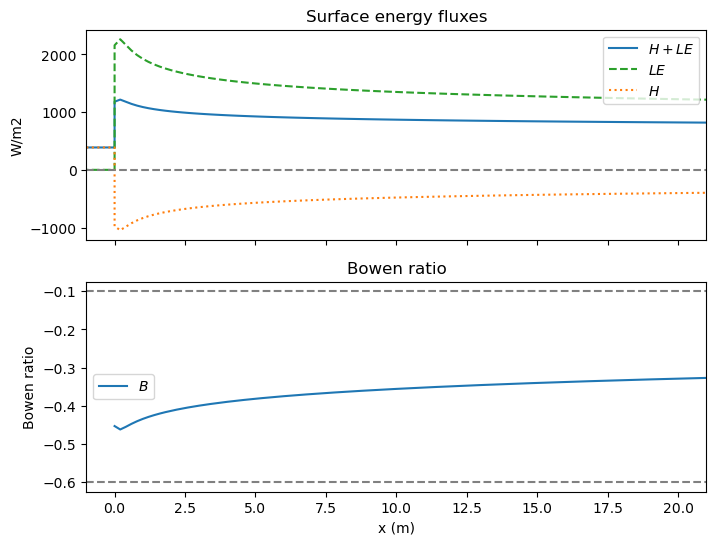

In [17]:
# --- Two-panel figure: surface energy fluxes (top) and Bowen ratio (bottom) ---
_level = level  # use the solver-level value from the main configuration cell
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)

# --- Top panel: H, LE, and H+LE along the fetch ---
ax = axes[0]

# Combine upwind (negative x) and downwind (positive x) into a single transect
xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, _level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[_level]*np.ones_like(x), LE_uniform_Wm2[:, _level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[_level]*np.ones_like(x), H_uniform_Wm2[:, _level]])

# Model curves
ax.plot(xx, FluxTotal_,  c =  'C0', ls = '-', label = '$H + LE$')
ax.plot(xx, LE_Wm2,  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(xx, H_Wm2,  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(-1, 21)
ax.legend()

# Rao (1974) Figure 4 reference points (circles) at x = 0, 2, 20 m


ax.set_ylabel("W/m2")
ax.set_title("Surface energy fluxes")
ax.axhline(0, ls = '--', c = 'grey')

# --- Bottom panel: Bowen ratio B = H / LE along the downwind fetch ---
ax = axes[1]
ax.plot(x, (H_uniform_Wm2[:, _level])/LE_uniform_Wm2[:, _level], label = "$B$")
ax.set_title("Bowen ratio")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
# Asymptotic reference lines for B
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')
plt.legend()


### Flux diagnostics
Sensible and latent heat flux profiles along fetch, Bowen ratio, and energy balance checks.

### Surface-level T, Q, and Bowen ratio along fetch

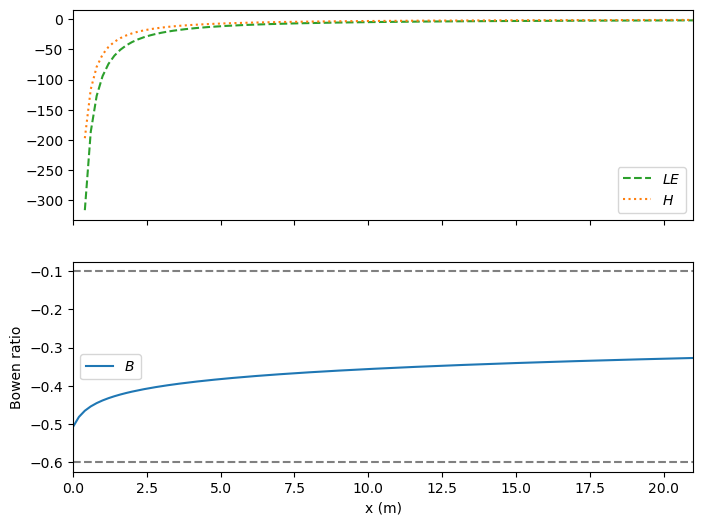

In [18]:
_level = 0  # surface fluxes
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, _level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[_level]*np.ones_like(x), LE_uniform_Wm2[:, _level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[_level]*np.ones_like(x), H_uniform_Wm2[:, _level]])

ax.plot(p.x[2:], np.diff(LE_uniform_Wm2[1:,_level]),  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(p.x[2:], - np.diff(H_uniform_Wm2[1:, _level]),  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, _level])/LE_uniform_Wm2[:, _level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

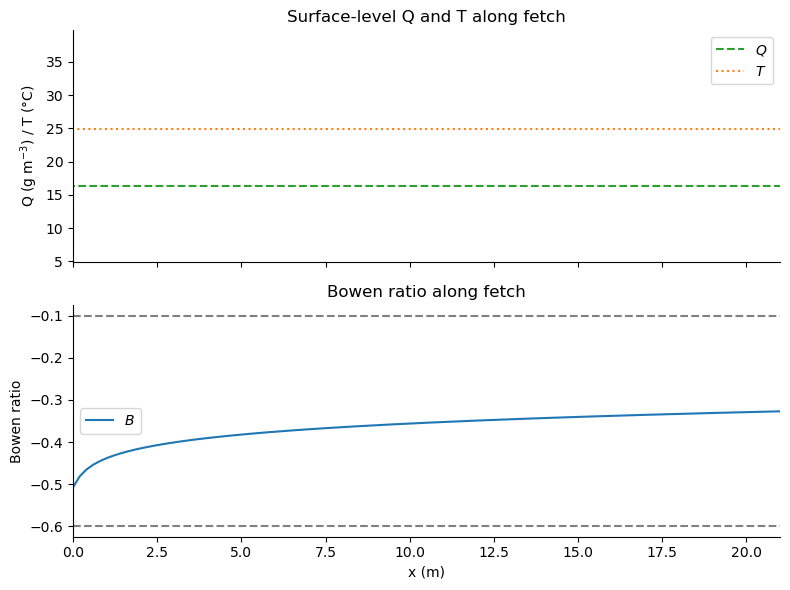

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

xx = np.concatenate([-np.flip(x), x])

_level = 0  # surface-level T, Q, and Bowen ratio
Q = np.concatenate([Q_up[_level] * np.ones_like(x), Q_uniform[:, _level]])
T = np.concatenate([T_up[_level] * np.ones_like(x), T_uniform[:, _level]])

# --- top panel: Q and T at surface level ---
ax = axes[0]
ax.plot(xx[1:], Q[1:], ls='--', c='C2', label="$Q$")
ax.plot(xx[1:], T[1:], ls=':', c='C1', label="$T$")
ax.set_xlim(0, 21)
ax.set_ylabel("Q (g m$^{-3}$) / T (°C)")
ax.set_title("Surface-level Q and T along fetch")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- bottom panel: Bowen ratio ---
ax = axes[1]
ax.plot(p.x, H_uniform_Wm2[:, _level] / LE_uniform_Wm2[:, _level], label="$B$")
ax.axhline(-0.1, ls='--', c='grey')
ax.axhline(-0.6, ls='--', c='grey')
ax.set_xlabel("x (m)")
ax.set_ylabel("Bowen ratio")
ax.set_title("Bowen ratio along fetch")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

In [20]:
# Upwind checks

H_wall_Wm2  =  p.ustar_f * p.k * (p.T_sf - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

print("H_f (AdvectionParams):       ", p.H_f)
print("H_wall:              {0:.2f}".format( H_wall_Wm2) ) 


# Downwind checks
# Lv_g = 2430.0  # J g^-1
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

print("\nLE_c (AdvectionParams):      ", p.LE_c)
print("LE_wall:             {0:.2f} ".format(LE_wall_Wm2))  


H_f (AdvectionParams):        355.64
H_wall:              355.64

LE_c (AdvectionParams):       864.2052000000001
LE_wall:             864.21 


\begin{aligned}
\mathrm{SW}\,(1-\alpha_f) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_f \,\sigma_{SB}\, T_{sf}^{4} &= R_{n,f}, \\
\mathrm{SW}\,(1-\alpha_c) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_c \,\sigma_{SB}\, T_{sc}^{4} &= R_{n,c}, \\
T_{sf} - T_a &= \frac{1}{k\,u_{*f}}\,
  \frac{H_f}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
T_{sc} - T_a &= \frac{1}{k\,u_{*c}}\,
  \frac{H_c}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
Q_c - Q_a &= \frac{1}{k\,u_{*c}}\,
  \frac{\mathrm{LE}_c}{L_v}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
R_{n,c} - G &= \mathrm{LE}_c + H_c .
\end{aligned}

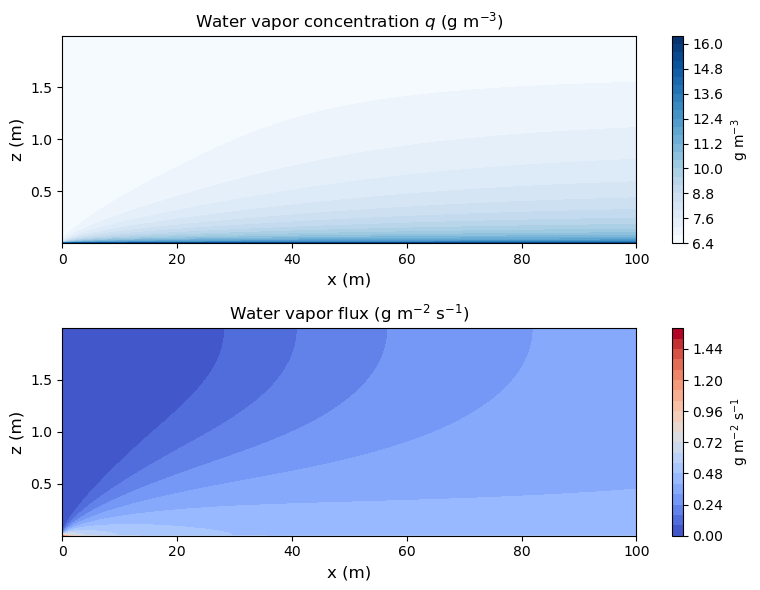

In [21]:
z = p.z
x = p.x

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
nz = Q_uniform.shape[1]
plt.contourf(x, z[:nz], (Q_uniform.T), 25, cmap='Blues',  vmax = p.Q_c, vmin =p.Q_a)
plt.colorbar(label='g m$^{-3}$')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (g m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z[:nz], FluxQ_uniform.T.round(4),  20, cmap='coolwarm', vmin = 0, vmax = FluxQ_uniform.max())
plt.colorbar(label='g m$^{-2}$ s$^{-1}$') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



### 2-D fields
Contour plots of Q and vertical moisture flux across the (x, z) domain.

In [22]:

_level = 1  # first interior grid point for rough estimate
# rough estimate at level height z:
z_eff = z[_level] - p.h_c*2/3
lm    = p.k * z_eff  
K     = lm * ustar_c
U = (p.ustar_f / p.k) * np.log(z / p.zom_c) 
Lrec  = U[_level] * z_eff / (p.k * ustar_c)   

In [23]:
Q_uniform.shape, p.z.shape

((501, 400), (400,))